In [2]:
"""
PHẦN 1: IMPORT THƯ VIỆN VÀ CẤU HÌNH
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import joblib
import warnings
import time

# Tắt cảnh báo
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
print("=" * 80)
print("MÔ HÌNH XGBoost TỐI ƯU - Huấn luyện trực tiếp (Tham số đã tinh chỉnh trước)")
print("=" * 80)

MÔ HÌNH XGBoost TỐI ƯU - Huấn luyện trực tiếp (Tham số đã tinh chỉnh trước)


In [3]:
"""
PHẦN 2: TẢI VÀ KHÁM PHÁ DỮ LIỆU
"""
print("\nĐANG TẢI DỮ LIỆU...")
print("-" * 80)

# Load dataset
df = pd.read_csv('../../datasets/raw/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

# Hiển thị thông tin cơ bản
print(f"Kích thước dataset: {df.shape}")
print(f"Số đặc trưng: {df.shape[1] - 1}")
print(f"Số mẫu: {df.shape[0]:,}")

# Phân bố nhãn
print(f"\nPhân bố nhãn mục tiêu:")
print(df['Diabetes_binary'].value_counts())
print(f"   - Không tiểu đường (0): {(df['Diabetes_binary'] == 0).sum():,} ({(df['Diabetes_binary'] == 0).sum()/len(df)*100:.1f}%)")
print(f"   - Tiểu đường (1): {(df['Diabetes_binary'] == 1).sum():,} ({(df['Diabetes_binary'] == 1).sum()/len(df)*100:.1f}%)")


ĐANG TẢI DỮ LIỆU...
--------------------------------------------------------------------------------
Kích thước dataset: (70692, 22)
Số đặc trưng: 21
Số mẫu: 70,692

Phân bố nhãn mục tiêu:
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64
   - Không tiểu đường (0): 35,346 (50.0%)
   - Tiểu đường (1): 35,346 (50.0%)


In [7]:
"""
PHẦN 3: XỬ LÝ DỮ LIỆU VÀ CÂN BẰNG MẪU
"""
print("\n" + "=" * 80)
print("XỬ LÝ DỮ LIỆU...")
print("-" * 80)

# Tách X và y
X = df.drop(['Diabetes_binary'], axis=1)
y = df['Diabetes_binary']

print(f"Một vài đặc trưng: {list(X.columns)[:5]}... (tổng: {len(X.columns)})")

# Chia tập train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTập huấn luyện: {X_train.shape[0]:,} mẫu")
print(f"Tập kiểm tra:   {X_test.shape[0]:,} mẫu")




XỬ LÝ DỮ LIỆU...
--------------------------------------------------------------------------------
Một vài đặc trưng: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker']... (tổng: 21)

Tập huấn luyện: 56,553 mẫu
Tập kiểm tra:   14,139 mẫu


In [8]:
"""
PHẦN 4: HUẤN LUYỆN MÔ HÌNH XGBoost
"""
print("\n" + "=" * 80)
print("BẮT ĐẦU HUẤN LUYỆN XGBoost VỚI THAM SỐ TỐI ƯU")
print("-" * 80)

# THAM SỐ TỐI ƯU (đã tinh chỉnh trước)
optimized_params = {
    'n_estimators': 250,
    'max_depth': 10,
    'learning_rate': 0.07,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'min_child_weight': 1,
    'gamma': 0.2,
    'reg_alpha': 0.3,
    'reg_lambda': 0.8,
    # 'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'logloss',
    'use_label_encoder': False
}

print("\nSử dụng tham số đã tinh chỉnh trước:")
for param, value in optimized_params.items():
    if param not in ['random_state', 'n_jobs', 'eval_metric', 'use_label_encoder']:
        print(f"   {param:<20} {value}")

# Khởi tạo và huấn luyện
xgb_model = XGBClassifier(**optimized_params)

print("\nĐang huấn luyện mô hình với tham số tối ưu...")
start_time = time.time()
xgb_model.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"Thời gian huấn luyện: {training_time:.2f} giây")


BẮT ĐẦU HUẤN LUYỆN XGBoost VỚI THAM SỐ TỐI ƯU
--------------------------------------------------------------------------------

Sử dụng tham số đã tinh chỉnh trước:
   n_estimators         250
   max_depth            10
   learning_rate        0.07
   subsample            0.7
   colsample_bytree     0.7
   min_child_weight     1
   gamma                0.2
   reg_alpha            0.3
   reg_lambda           0.8

Đang huấn luyện mô hình với tham số tối ưu...
Thời gian huấn luyện: 1.26 giây


In [9]:
"""
PHẦN 5: TỐI ƯU NGƯỠNG QUYẾT ĐỊNH
"""
print("\n" + "=" * 80)
print("TỐI ƯU NGƯỠNG QUYẾT ĐỊNH...")
print("-" * 80)

# Dự đoán xác suất
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Kiểm tra các ngưỡng khác nhau
print("\nKiểm tra các ngưỡng:")
print(f"{'Ngưỡng':<12} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1-Score':<10}")
print("-" * 80)

best_threshold = 0.5
best_f1 = 0
best_metrics = {}

thresholds_to_test = np.linspace(0.25, 0.65, 81)

for threshold in thresholds_to_test:
    y_pred_adjusted = (y_pred_proba >= threshold).astype(int)
    
    acc = accuracy_score(y_test, y_pred_adjusted)
    prec = precision_score(y_test, y_pred_adjusted)
    rec = recall_score(y_test, y_pred_adjusted)
    f1 = f1_score(y_test, y_pred_adjusted)
    
    # Hiển thị một số ngưỡng chính
    if threshold in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
        print(f"{threshold:<12.2f} {acc:<10.4f} {prec:<12.4f} {rec:<10.4f} {f1:<10.4f}")
    
    # Lưu ngưỡng tốt nhất
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_metrics = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'y_pred': y_pred_adjusted
        }

print(f"\nNgưỡng tối ưu: {best_threshold:.3f}")
print(f"F1-Score tối đa: {best_f1:.4f}")

y_pred = best_metrics['y_pred']


TỐI ƯU NGƯỠNG QUYẾT ĐỊNH...
--------------------------------------------------------------------------------

Kiểm tra các ngưỡng:
Ngưỡng       Accuracy   Precision    Recall     F1-Score  
--------------------------------------------------------------------------------
0.25         0.7138     0.6490       0.9310     0.7648    
0.30         0.7270     0.6658       0.9116     0.7695    
0.35         0.7337     0.6789       0.8870     0.7691    
0.40         0.7394     0.6944       0.8550     0.7664    
0.45         0.7409     0.7094       0.8160     0.7589    
0.50         0.7437     0.7265       0.7816     0.7530    
0.55         0.7404     0.7424       0.7360     0.7392    

Ngưỡng tối ưu: 0.310
F1-Score tối đa: 0.7701


In [10]:
"""
PHẦN 6: ĐÁNH GIÁ MÔ HÌNH
"""
print("\n" + "=" * 80)
print("ĐÁNH GIÁ MÔ HÌNH")
print("-" * 80)

# Tính các chỉ số
accuracy = best_metrics['accuracy']
precision = best_metrics['precision']
recall = best_metrics['recall']
f1 = best_metrics['f1']
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nCÁC CHỈ SỐ HIỆU NĂNG:")
print(f"   {'Accuracy:':<15} {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   {'Precision:':<15} {precision:.4f} ({precision*100:.2f}%)")
print(f"   {'Recall:':<15} {recall:.4f} ({recall*100:.2f}%)")
print(f"   {'F1-Score:':<15} {f1:.4f}")
print(f"   {'ROC-AUC:':<15} {roc_auc:.4f}")
print(f"   {'Ngưỡng:':<15} {best_threshold:.3f}")

# Kiểm tra cân bằng
print("\nKIỂM TRA CÂN BẰNG GIỮA PRECISION VÀ RECALL:")
balance_score = abs(precision - recall)
if balance_score < 0.05:
    print(f"   Rất cân bằng! Precision ≈ Recall (chênh: {balance_score:.3f})")
elif balance_score < 0.10:
    print(f"   Khá cân bằng! Precision ≈ Recall (chênh: {balance_score:.3f})")
else:
    print(f"   Cân bằng trung bình (chênh Precision-Recall: {balance_score:.3f})")

# Báo cáo phân loại
print(f"\nBÁO CÁO PHÂN LOẠI:")
print("-" * 80)
print(classification_report(y_test, y_pred, target_names=['Không tiểu đường', 'Tiểu đường']))

# Ma trận nhầm lẫn
print(f"\nMA TRẬN NHẦM LẪN:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0

print(f"\n   True Negatives:  {tn:,} ({specificity*100:.1f}% specificity)")
print(f"   False Positives: {fp:,} ({(fp/(tn+fp)*100 if (tn+fp)>0 else 0.0):.1f}% false alarm rate)")
print(f"   False Negatives: {fn:,} ({(fn/(fn+tp)*100 if (fn+tp)>0 else 0.0):.1f}% miss rate)")
print(f"   True Positives:  {tp:,} ({sensitivity*100:.1f}% sensitivity/recall)")

print(f"\nDIỄN GIẢI:")
print(f"   Tỷ lệ phát hiện: {recall*100:.1f}% số ca tiểu đường được phát hiện")
print(f"   Precision: {precision*100:.1f}% các dự đoán dương là chính xác")
print(f"   Tỷ lệ báo động sai: {(fp/(tn+fp)*100 if (tn+fp)>0 else 0.0):.1f}% người khỏe bị gắn cờ")
print(f"   Tỷ lệ bỏ sót: {(fn/(fn+tp)*100 if (fn+tp)>0 else 0.0):.1f}% ca tiểu đường bị bỏ sót")


ĐÁNH GIÁ MÔ HÌNH
--------------------------------------------------------------------------------

CÁC CHỈ SỐ HIỆU NĂNG:
   Accuracy:       0.7290 (72.90%)
   Precision:      0.6688 (66.88%)
   Recall:         0.9075 (90.75%)
   F1-Score:       0.7701
   ROC-AUC:        0.8211
   Ngưỡng:         0.310

KIỂM TRA CÂN BẰNG GIỮA PRECISION VÀ RECALL:
   Cân bằng trung bình (chênh Precision-Recall: 0.239)

BÁO CÁO PHÂN LOẠI:
--------------------------------------------------------------------------------
                  precision    recall  f1-score   support

Không tiểu đường       0.86      0.55      0.67      7070
      Tiểu đường       0.67      0.91      0.77      7069

        accuracy                           0.73     14139
       macro avg       0.76      0.73      0.72     14139
    weighted avg       0.76      0.73      0.72     14139


MA TRẬN NHẦM LẪN:
[[3893 3177]
 [ 654 6415]]

   True Negatives:  3,893 (55.1% specificity)
   False Positives: 3,177 (44.9% false alarm rate)


In [13]:
"""
PHẦN 7: PHÂN TÍCH ĐẶC TRƯNG QUAN TRỌNG
"""
print("\n" + "=" * 80)
print("TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT")
print("-" * 80)

# Tính feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n")
for idx, row in feature_importance.head(15).iterrows():
    print(f"   {row['feature']:<25} {row['importance']:.4f}")

# Lưu feature importance
feature_importance.to_csv('feature_importance_2.csv', index=False)
print("\nĐã lưu feature importance vào 'feature_importance_2.csv'")


TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT
--------------------------------------------------------------------------------


   HighBP                    0.2372
   GenHlth                   0.1455
   CholCheck                 0.0713
   HighChol                  0.0542
   HvyAlcoholConsump         0.0472
   Age                       0.0427
   BMI                       0.0364
   HeartDiseaseorAttack      0.0362
   DiffWalk                  0.0342
   Stroke                    0.0271
   Sex                       0.0269
   Income                    0.0261
   PhysHlth                  0.0254
   MentHlth                  0.0249
   AnyHealthcare             0.0243

Đã lưu feature importance vào 'feature_importance_2.csv'



TẠO HÌNH ẢNH MINH HỌA...
--------------------------------------------------------------------------------


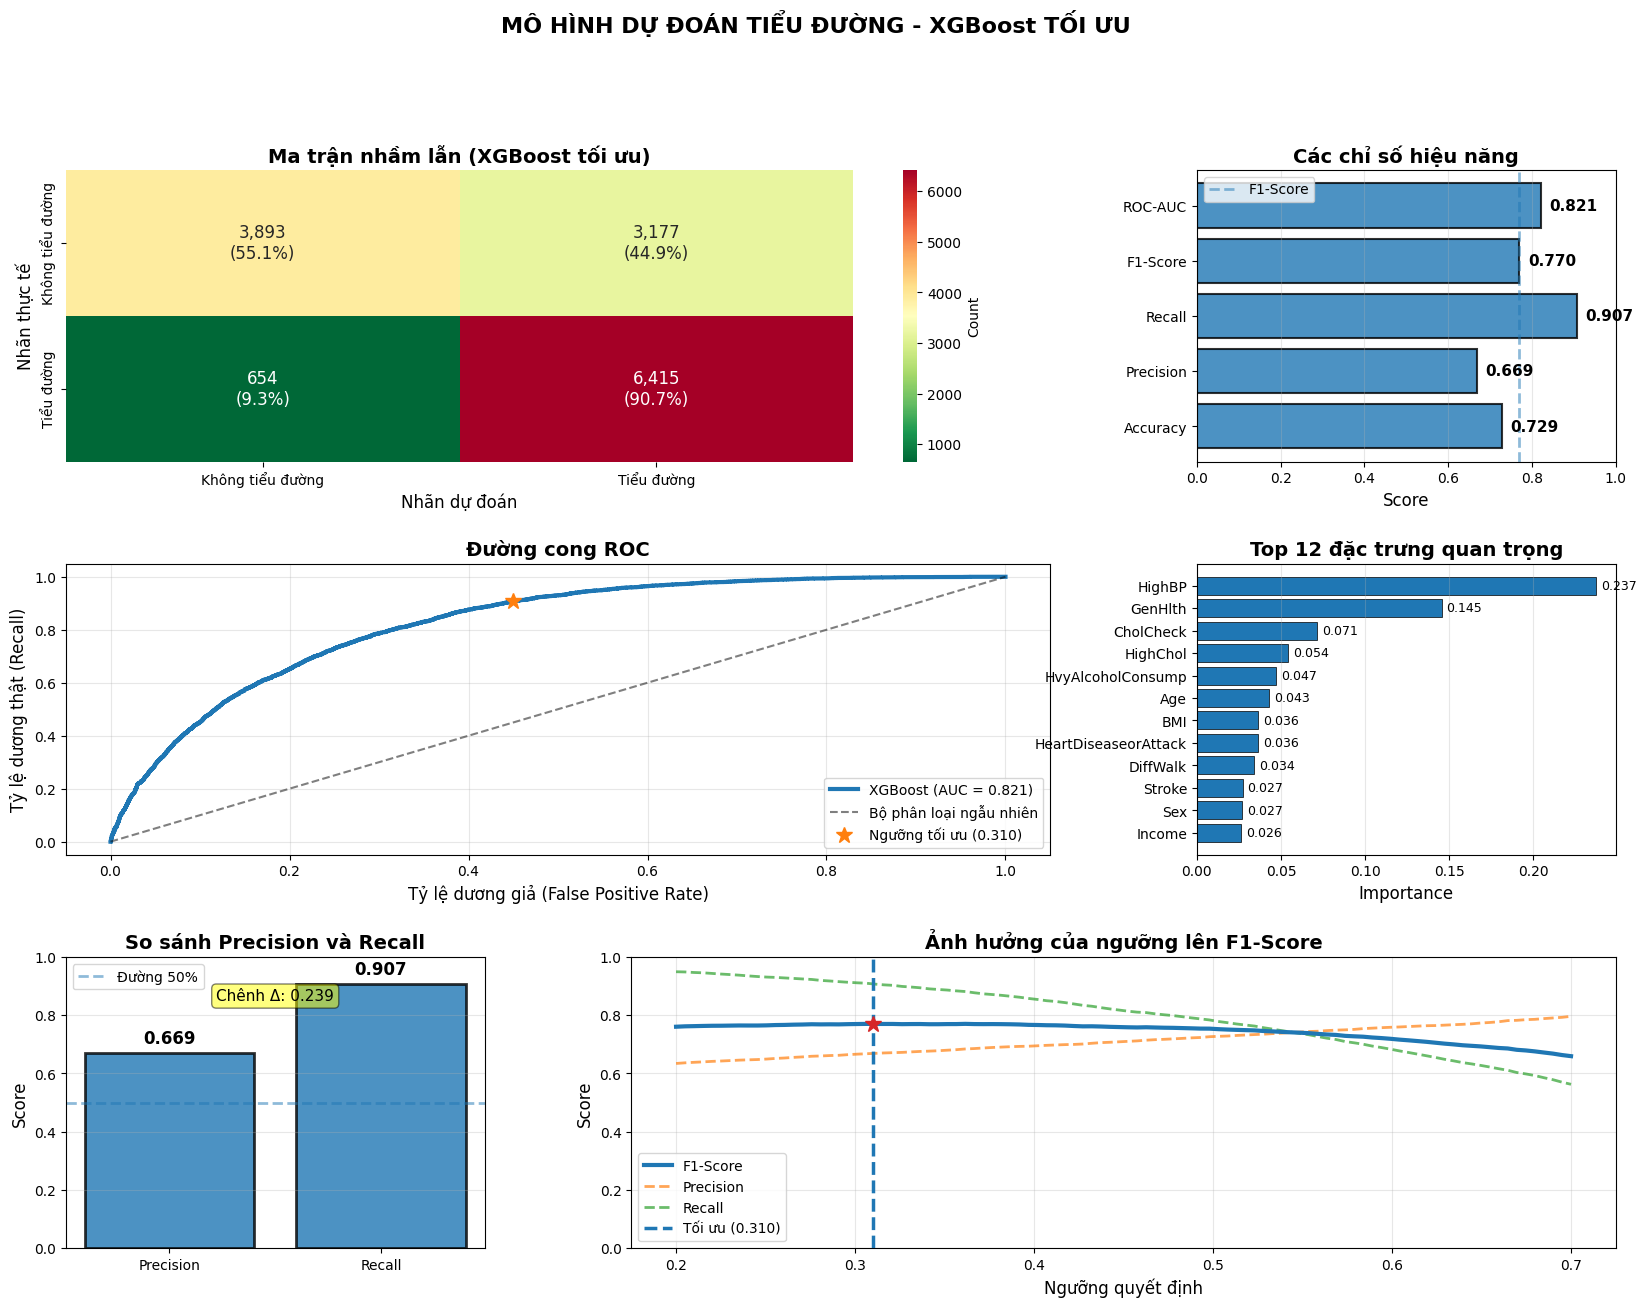

In [14]:
"""
PHẦN 8: TẠO HÌNH ẢNH MINH HỌA
"""
print("\n" + "=" * 80)
print("TẠO HÌNH ẢNH MINH HỌA...")
print("-" * 80)

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# 1. Ma trận nhầm lẫn
ax1 = fig.add_subplot(gs[0, :2])
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
annot_text = np.array([[f'{cm[i,j]:,}\n({cm_percent[i,j]:.1f}%)' 
                        for j in range(cm.shape[1])] 
                       for i in range(cm.shape[0])])
sns.heatmap(cm, annot=annot_text, fmt='', cmap='RdYlGn_r', ax=ax1, 
            cbar_kws={'label': 'Count'}, annot_kws={'size': 12})
ax1.set_title('Ma trận nhầm lẫn (XGBoost tối ưu)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Nhãn dự đoán', fontsize=12)
ax1.set_ylabel('Nhãn thực tế', fontsize=12)
ax1.set_xticklabels(['Không tiểu đường', 'Tiểu đường'])
ax1.set_yticklabels(['Không tiểu đường', 'Tiểu đường'])

# 2. Các chỉ số hiệu năng
ax2 = fig.add_subplot(gs[0, 2])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [accuracy, precision, recall, f1, roc_auc]

bars = ax2.barh(metrics_names, metrics_values, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlim([0, 1])
ax2.set_xlabel('Score', fontsize=12)
ax2.set_title('Các chỉ số hiệu năng', fontsize=14, fontweight='bold')

for i, (bar, value) in enumerate(zip(bars, metrics_values)):
    ax2.text(value + 0.02, i, f'{value:.3f}', va='center', fontsize=11, fontweight='bold')

ax2.axvline(x=f1, linestyle='--', linewidth=2, alpha=0.5, label='F1-Score')
ax2.grid(axis='x', alpha=0.3)
ax2.legend()

# 3. Đường cong ROC
ax3 = fig.add_subplot(gs[1, :2])
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
ax3.plot(fpr, tpr, linewidth=3, label=f'XGBoost (AUC = {roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Bộ phân loại ngẫu nhiên', alpha=0.5)

threshold_idx = np.argmin(np.abs(thresholds_roc - best_threshold))
ax3.plot(fpr[threshold_idx], tpr[threshold_idx], '*', markersize=12, 
         label=f'Ngưỡng tối ưu ({best_threshold:.3f})')

ax3.set_xlabel('Tỷ lệ dương giả (False Positive Rate)', fontsize=12)
ax3.set_ylabel('Tỷ lệ dương thật (Recall)', fontsize=12)
ax3.set_title('Đường cong ROC', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10, loc='lower right')
ax3.grid(alpha=0.3)

# 4. Feature Importance
ax4 = fig.add_subplot(gs[1, 2])
top_features = feature_importance.head(12)
bars_feat = ax4.barh(range(len(top_features)), top_features['importance'], edgecolor='black', linewidth=0.5)
ax4.set_yticks(range(len(top_features)))
ax4.set_yticklabels(top_features['feature'], fontsize=10)
ax4.set_xlabel('Importance', fontsize=12)
ax4.set_title('Top 12 đặc trưng quan trọng', fontsize=14, fontweight='bold')
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars_feat, top_features['importance'])):
    ax4.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=9)

# 5. So sánh Precision và Recall
ax5 = fig.add_subplot(gs[2, 0])
metrics_balance = ['Precision', 'Recall']
values_balance = [precision, recall]
bars_balance = ax5.bar(metrics_balance, values_balance, alpha=0.8, edgecolor='black', linewidth=2)
ax5.set_ylim([0, 1])
ax5.set_ylabel('Score', fontsize=12)
ax5.set_title('So sánh Precision và Recall', fontsize=14, fontweight='bold')
ax5.axhline(y=0.5, linestyle='--', linewidth=2, alpha=0.5, label='Đường 50%')
ax5.grid(axis='y', alpha=0.3)

for bar, val in zip(bars_balance, values_balance):
    ax5.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

balance_diff = abs(precision - recall)
ax5.text(0.5, 0.85, f'Chênh Δ: {balance_diff:.3f}', 
         ha='center', fontsize=11, 
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
ax5.legend()

# 6. Ảnh hưởng của ngưỡng lên các chỉ số
ax6 = fig.add_subplot(gs[2, 1:])
thresh_range = np.linspace(0.2, 0.7, 100)
recalls = []
precisions = []
f1s = []

for thresh in thresh_range:
    y_pred_temp = (y_pred_proba >= thresh).astype(int)
    recalls.append(recall_score(y_test, y_pred_temp))
    precisions.append(precision_score(y_test, y_pred_temp))
    f1s.append(f1_score(y_test, y_pred_temp))

ax6.plot(thresh_range, f1s, '-', linewidth=3, label='F1-Score', zorder=3)
ax6.plot(thresh_range, precisions, '--', linewidth=2, label='Precision', alpha=0.7)
ax6.plot(thresh_range, recalls, '--', linewidth=2, label='Recall', alpha=0.7)

ax6.axvline(x=best_threshold, linestyle='--', linewidth=2.5, label=f'Tối ưu ({best_threshold:.3f})', zorder=4)
ax6.plot(best_threshold, f1, '*', markersize=12, zorder=5)

ax6.set_xlabel('Ngưỡng quyết định', fontsize=12)
ax6.set_ylabel('Score', fontsize=12)
ax6.set_title('Ảnh hưởng của ngưỡng lên F1-Score', fontsize=14, fontweight='bold')
ax6.legend(fontsize=10, loc='best')
ax6.grid(alpha=0.3)
ax6.set_ylim([0, 1])

plt.suptitle('MÔ HÌNH DỰ ĐOÁN TIỂU ĐƯỜNG - XGBoost TỐI ƯU', 
             fontsize=16, fontweight='bold', y=0.995)

# plt.savefig('xgboost_optimized_final_model.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
"""
PHẦN 9: LƯU MÔ HÌNH
"""
print("\n" + "=" * 80)
print("LƯU MÔ HÌNH...")
print("-" * 80)

# Chuẩn bị dữ liệu mô hình
XGBoost = {
    'model': xgb_model,
    'threshold': best_threshold,
    'optimized_params': optimized_params,
    'feature_names': list(X.columns),
    'metrics': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc
    },
    'training_time': training_time
}

# Lưu model
joblib.dump(XGBoost, '../../models/xgboost_model.pkl')

print("Mô hình đã lưu dưới tên 'xgboost_model.pkl'")
print(f"   Tham số: Cấu hình tối ưu đã tinh chỉnh trước")
print(f"   Ngưỡng: {best_threshold:.3f}")
print(f"   F1-Score: {f1:.4f}")
print(f"   ROC-AUC: {roc_auc:.4f}")


LƯU MÔ HÌNH...
--------------------------------------------------------------------------------
Mô hình đã lưu dưới tên 'xgboost_model.pkl'
   Tham số: Cấu hình tối ưu đã tinh chỉnh trước
   Ngưỡng: 0.310
   F1-Score: 0.7701
   ROC-AUC: 0.8211


In [16]:
"""
PHẦN 10: VÍ DỤ DỰ ĐOÁN VÀ TỔNG KẾT
"""
print("\n" + "=" * 80)
print("VÍ DỤ DỰ ĐOÁN")
print("-" * 80)

for i in range(5):
    sample_idx = np.random.randint(0, len(X_test))
    sample = X_test.iloc[sample_idx:sample_idx+1]
    sample_true = y_test.iloc[sample_idx]

    # Predict
    proba = xgb_model.predict_proba(sample)[0]
    prediction = 1 if proba[1] >= best_threshold else 0

    # Confidence level
    confidence = max(proba)
    confidence_level = (
        "Cao" if confidence > 0.8 else
        "Trung bình" if confidence > 0.6 else
        "Thấp"
    )

    # Icons for labels
    true_label_icon = "🔴 Diabetes" if sample_true == 1 else "🟢 No Diabetes"
    pred_label_icon = "🔴 Diabetes" if prediction == 1 else "🟢 No Diabetes"

    # Status (✔ / ✖)
    status_icon = "✔ CHÍNH XÁC" if prediction == sample_true else "✖ KHÔNG CHÍNH XÁC"

    print(f"\nVí dụ #{i+1} (Mẫu #{sample_idx}):")
    print(f"   Nhãn thực tế: {true_label_icon}")
    print(f"   Dự đoán:      {pred_label_icon}")
    print(f"   Xác suất:     Diabetes={proba[1]*100:.1f}%, No Diabetes={proba[0]*100:.1f}%")
    print(f"   Mức độ tin cậy: {confidence_level} ({confidence*100:.1f}%)")
    print(f"   Kết quả: {status_icon}")



VÍ DỤ DỰ ĐOÁN
--------------------------------------------------------------------------------

Ví dụ #1 (Mẫu #4622):
   Nhãn thực tế: 🔴 Diabetes
   Dự đoán:      🔴 Diabetes
   Xác suất:     Diabetes=93.6%, No Diabetes=6.4%
   Mức độ tin cậy: Cao (93.6%)
   Kết quả: ✔ CHÍNH XÁC

Ví dụ #2 (Mẫu #6736):
   Nhãn thực tế: 🔴 Diabetes
   Dự đoán:      🔴 Diabetes
   Xác suất:     Diabetes=90.1%, No Diabetes=9.9%
   Mức độ tin cậy: Cao (90.1%)
   Kết quả: ✔ CHÍNH XÁC

Ví dụ #3 (Mẫu #5737):
   Nhãn thực tế: 🟢 No Diabetes
   Dự đoán:      🟢 No Diabetes
   Xác suất:     Diabetes=6.7%, No Diabetes=93.3%
   Mức độ tin cậy: Cao (93.3%)
   Kết quả: ✔ CHÍNH XÁC

Ví dụ #4 (Mẫu #4642):
   Nhãn thực tế: 🔴 Diabetes
   Dự đoán:      🔴 Diabetes
   Xác suất:     Diabetes=51.4%, No Diabetes=48.6%
   Mức độ tin cậy: Thấp (51.4%)
   Kết quả: ✔ CHÍNH XÁC

Ví dụ #5 (Mẫu #13133):
   Nhãn thực tế: 🟢 No Diabetes
   Dự đoán:      🟢 No Diabetes
   Xác suất:     Diabetes=18.9%, No Diabetes=81.1%
   Mức độ tin cậy: Cao 